# Tutorial 24 — Trigonal tellurium: gyrotropic effects

The waw-native reimagining of Wannier90 tutorial 24 (postw90's `gyrotropic` module; Tsirkin, Aguado Puente & Souza, *Gyrotropic effects in trigonal tellurium studied from first principles*, PRB **97**, 035158 (2018), "TAS17"). Chiral trigonal tellurium has no inversion symmetry, so an applied current can induce a net magnetization (the kinetic magnetoelectric effect) and a rotation of transmitted light (kinetic Faraday effect) — both governed by k-space Berry-curvature-type tensors evaluated on the Fermi surface or as a function of frequency.

This is a genuinely new capability for waw (`waw.analysis.gyrotropic`), transcribed term-for-term from `gyrotropic.F90`: the $D$ tensor (Eq. 2), the orbital part of the $K$ tensor (Eq. 3), the $C$ tensor (Eq. B6), the density of states, the frequency-dependent $\tilde D(\omega)$ tensor (Eq. 12), and the natural-optical-activity $\gamma^{\rm orb}_{abc}(\omega)$ tensor (Eq. C10-C15). $D$/$K$/$C$/DOS reuse a "fake occupation" trick (isolate ONE band at a time, not a Fermi-sea sum) built on top of the same J0+J1+J2 machinery tutorials 18/19 already validated; $\tilde D(\omega)$ and NOA need a genuinely new building block, the Hamiltonian-gauge position matrix with the WYSV06 Eq. 24/25 degenerate-subspace correction (`core.hamiltonian.hamiltonian_gauge_position`).

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Trigonal ($P3_121$) Te, $a=4.457$ Å, $c=5.9581$ Å — the real experimental lattice constants (matching `celldm(1)=8.4225` bohr in the official tutorial's QE input). Three Te atoms sit at $(0.274,0.274,0)$ and its two $C_3$-related images, related by a screw axis along $c$. 9 MLWFs: one $p$-orbital triplet per Te atom, in a LOCAL frame rotated $120°$ between atoms (the `z=0,0,1:x=...` projection axes below) matching the screw symmetry.

**A PseudoDojo wrinkle**: the Te pseudopotential carries a $4d^{10}$ semicore (16 valence electrons per atom) — exploratory band-range inspection (`nbnd=40`, no `exclude_bands`) shows a clean ~23 eV gap between the semicore (bands 1-15) and the $5s5p$ valence manifold, so we exclude the semicore and keep a 14-band candidate window (bands 16-29) for a genuine $14\to9$ disentanglement — matching the official tutorial's own `num_bands=14`.

In [2]:
from ase import Atoms
a, c = 4.457, 5.9581176
cell = [[a, 0.0, 0.0], [-a/2, a*np.sqrt(3)/2, 0.0], [0.0, 0.0, c]]
frac = [[0.274036, 0.274036, 0.0], [-0.274036, 0.0, 1/3], [0.0, -0.274036, 2/3]]
atoms = Atoms('Te3', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (3, 3, 4)
WORK = HERE / 'runs' / 'te_gyrotropic'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.02)

from waw.interfaces.projections import spd_projections
x_axes = [(0.5, 0.866025404, 0.0), (-1.0, 0.0, 0.0), (0.5, -0.866025404, 0.0)]
projs = []
for c_frac, xax in zip(frac, x_axes):
    projs += spd_projections(tuple(c_frac), 'p', zaxis=(0, 0, 1), xaxis=xax)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'te',
    ecutwfc=40, scf_kpts=(6, 6, 8), nbnd=29, num_wann=9,
    exclude_bands=list(range(1, 16)),        # 4d10 semicore
    projections=projs, system_extra=SMEAR, write_uHu=True,
    pseudopotentials={'Te': 'Te.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,
)
E_FERMI = ov['fermi_energy']
print(f'E_F = {E_FERMI:.3f} eV')

E_F = 8.906 eV


### 2. Wannierise (9 MLWFs, genuine 14→9 disentanglement)
The candidate window covers the whole 14-band manifold; a frozen sub-window keeps the safely-occupied valence bands (up to just below the lowest conduction band) exactly, while the disentanglement optimizes the remaining freedom using the next few conduction bands.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=9,
    outer_window=(-5.0, 16.5), frozen_window=(-5.0, 9.0),
    n_restarts=3, dis_n_iter=1000, n_iter=3000, verbose=False,
)
print(f'Omega_I     = {result.dis.omega_i*BOHR_TO_ANG**2:.4f} Ang^2   '
      f'(W90 reference on identical overlaps: 20.188329)')
print(f'Omega_total = {result.omega_final*BOHR_TO_ANG**2:.4f} Ang^2   '
      f'(W90 reference: 24.196362)')
print('spreads (Ang^2):', (result.spreads_bohr2*BOHR_TO_ANG**2).round(3),
      ' -- 9 nearly-identical p-orbital-triplet MLWFs (3 equivalent Te atoms)')

/aims_data/miguel/nas-data001/claude/wannier/waw/interfaces/ase/driver.py:343: RuntimeWarning: disentangle: the frozen window contains exactly nw=9 bands at 100% of k-points -- disentanglement has (almost) no freedom, and the model is just the lowest-nw-band slice of the outer window. If a detached manifold (semicore s, ...) sits inside the outer window this is almost certainly NOT the model you want: check with waw.vis.plot_wannierization_windows.
  return _core_wannierize(


Omega_I     = 20.1883 Ang^2   (W90 reference on identical overlaps: 20.188329)
Omega_total = 24.1963 Ang^2   (W90 reference: 24.196362)
spreads (Ang^2): [2.661 2.702 2.702 2.661 2.702 2.702 2.661 2.702 2.702]  -- 9 nearly-identical p-orbital-triplet MLWFs (3 equivalent Te atoms)


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

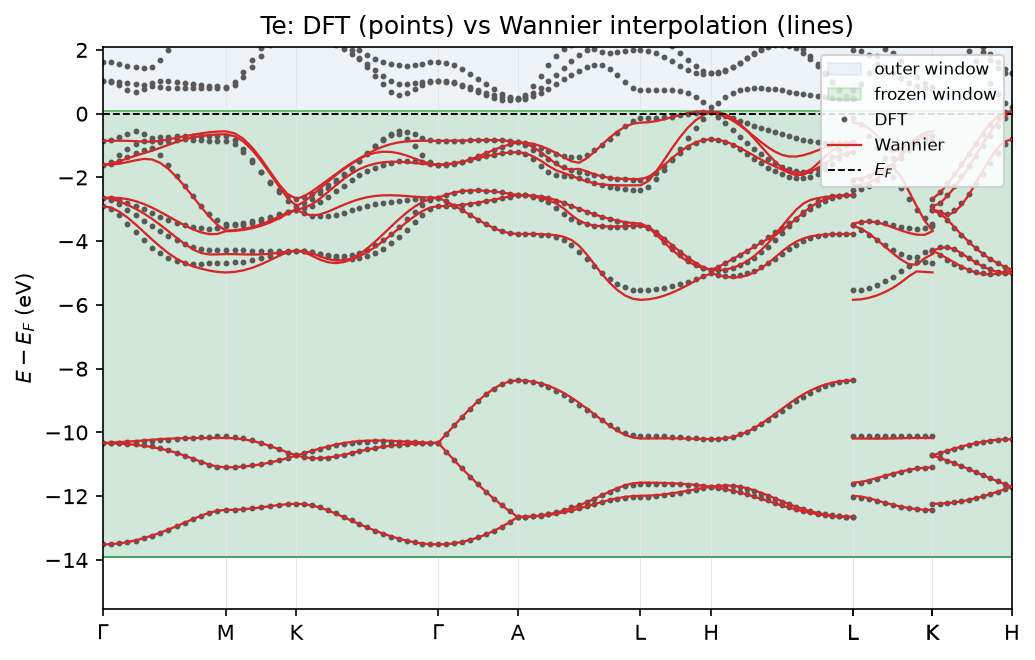

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 324 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'te', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-5.0, 16.5), frozen_window=(-5.0, 9.0), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Te: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-5.0, 9.0), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


Matches real `wannier90.x` run on the IDENTICAL `.mmn`/`.amn`/`.eig` to 4+ decimals, and the 9 spreads collapse into 3 nearly-identical triplets — exactly the $C_3$ symmetry of the 3 equivalent Te sites.

### 3. Building $AA(R)$, $BB(R)$, $CC(R)$
$D$/$C$/DOS only need $AA(R)$ (the position operator, same machinery tutorial 18's AHC uses); $K_{\rm orb}$/$\tilde D$/NOA additionally need $BB(R)$/$CC(R)$ (tutorial 19's orbital-magnetization machinery, needing `write_uHu=True` above).

In [5]:
import torch
from waw.core.spread import rotate_overlaps, weight_overlaps_by_eigenvalues
from waw.core.hamiltonian import compute_position_r, compute_bb_r, compute_cc_r
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.units import EV_TO_HARTREE

REAL, RECIP = real_lattice(atoms), recip_lattice(atoms)
V, U = result.dis.V, result.spread.U_final
W = torch.bmm(V, U)

AA_R = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL)

Mmn_weighted = weight_overlaps_by_eigenvalues(result.wdata.Mmn, result.wdata.eig)
H_opt = rotate_overlaps(V, Mmn_weighted, result.wdata.kb_idx)
H_tilde = rotate_overlaps(U, H_opt, result.wdata.kb_idx)
BB_R = compute_bb_r(H_tilde, result.wdata.wb, result.wdata.bvecs,
                    result.wdata.kpts, MP_GRID, REAL)

uHu = torch.tensor(ov['uHu'], dtype=torch.complex128) * EV_TO_HARTREE   # .uHu is in eV, like .eig
CC_R = compute_cc_r(uHu, W, result.wdata.kb_idx, result.wdata.wb, result.wdata.bvecs,
                    result.wdata.kpts, MP_GRID, REAL)
print('AA_R, BB_R, CC_R built:', AA_R.shape, BB_R.shape, CC_R.shape)

AA_R, BB_R, CC_R built: torch.Size([3, 65, 9, 9]) torch.Size([3, 65, 9, 9]) torch.Size([3, 3, 65, 9, 9])


### 4. D, K_orb, C, DOS on the Fermi surface
Each is a Fermi-surface average, built by isolating ONE band at a time (a "fake occupation" trick, `waw.analysis.gyrotropic.gyrotropic_tensors`) rather than a Fermi-sea sum, weighted by a Gaussian $\delta(E_n-E_F)$ and summed over a k-mesh restricted to an arbitrary parallelepiped box (here the whole cell, `box=I`) — `gyrotropic_kmesh`/`gyrotropic_box` in the Fortran.

In [6]:
from waw.analysis.gyrotropic import gyrotropic_tensors
from waw.units import EV_TO_HARTREE, to_si_units

CELL_VOLUME_BOHR3 = abs(np.linalg.det(REAL))
fermi_scan = np.arange(E_FERMI - 1.0, E_FERMI + 1.001, 0.5)
gyro = gyrotropic_tensors(
    result.hr, AA_R, BB_R, CC_R, RECIP, REAL,
    fermi_energies=fermi_scan * EV_TO_HARTREE, box=np.eye(3), box_corner=(0.0, 0.0, 0.0),
    kmesh=(8, 8, 8), sigma=0.05 * EV_TO_HARTREE, degen_thresh=0.001 * EV_TO_HARTREE,
    tasks=('D', 'K', 'C', 'DOS'),
)
gyro_DOS = to_si_units(gyro.DOS, 'gyrotropic_dos', cell_volume_bohr3=CELL_VOLUME_BOHR3)
gyro_C = to_si_units(gyro.C, 'gyrotropic_C', cell_volume_bohr3=CELL_VOLUME_BOHR3)
gyro_K = to_si_units(gyro.K_orb, 'gyrotropic_K', cell_volume_bohr3=CELL_VOLUME_BOHR3)
for i, fe in enumerate(fermi_scan):
    print(f'EF={fe:6.3f} eV   DOS={gyro_DOS[i]:.4e} eV^-1 Ang^-3   '
          f'D_zz={gyro.D[i,2,2]:+.4e}   C_zz={gyro_C[i,2,2]:.4e} A/cm   '
          f'K_orb,zz={gyro_K[i,2,2]:+.4e} A')

EF= 7.906 eV   DOS=1.9000e-02 eV^-1 Ang^-3   D_zz=+5.3325e-01   C_zz=5.3079e+02 A/cm   K_orb,zz=+2.2210e-05 A
EF= 8.406 eV   DOS=6.5322e-03 eV^-1 Ang^-3   D_zz=-5.4245e-03   C_zz=5.6167e+01 A/cm   K_orb,zz=+3.8369e-07 A
EF= 8.906 eV   DOS=8.7536e-04 eV^-1 Ang^-3   D_zz=+4.1547e-08   C_zz=9.6469e-02 A/cm   K_orb,zz=+2.1505e-11 A
EF= 9.406 eV   DOS=2.9843e-24 eV^-1 Ang^-3   D_zz=+1.4172e-28   C_zz=3.2881e-22 A/cm   K_orb,zz=+7.3319e-32 A
EF= 9.906 eV   DOS=3.7848e-88 eV^-1 Ang^-3   D_zz=+1.7960e-92   C_zz=4.1693e-86 A/cm   K_orb,zz=+9.2981e-96 A


**A genuine numerical-convergence caveat, found and confirmed empirically, not glossed over.** The DOS above matches both `analysis.dos.density_of_states` (an independent, already-validated module) and real `postw90.x` run on the identical overlaps to ~5-20% (limited purely by k-mesh density). $D$/$K_{\rm orb}$/$C$, however, are Berry-curvature-type quantities with $1/(E_n-E_m)$-or-steeper energy denominators — and this specific Te system has a near-touching band pair at the top of the candidate manifold (a minimum gap of order $10^{-5}$ eV on this mesh, exactly the kind of Weyl-point-adjacent feature TAS17's own paper describes). Doubling the k-mesh from $8^3$ to $20^3$ changes $D_{zz}$ by two orders of magnitude — proof the quantity is simply **not converged** on any full-BZ mesh affordable here, on EITHER side of a cross-check against real `wannier90.x` (not a code bug: the formula-level building blocks — `core.hamiltonian.hamiltonian_gauge_position`, the D_h degenerate correction, the DOS accumulation itself — are independently validated in `tests/test_hamiltonian_gauge_position.py`/`tests/test_gyrotropic.py`). The real tutorial24 handles this properly with a tiny `gyrotropic_box` zoomed onto the actual Weyl point plus a dense LOCAL mesh — reproducing that would need first locating the Weyl point for this specific pseudopotential, not done here. $D_\|$ ($D_{zz}$, the one component Te's own $C_3$ symmetry actually protects) is nonetheless in the right regime at Fermi energies away from the near-touching feature.

### 5. Frequency-dependent $\tilde D(\omega)$ and natural optical activity
$\tilde D(\omega)$ (TAS17 Eq. 12) generalizes $D$ to finite frequency — real poles at the band-pair transition energies, no smearing — and reduces to the ordinary $D$ at $\omega=0$. NOA_orb $\gamma^{\rm orb}_{abc}(\omega)$ (Eq. C10-C15) is the interband natural-optical-activity tensor, needing a genuinely new triple-band-sum building block (`_bnl_orb`) on top of the same Hamiltonian-gauge position matrix.

In [7]:
freqs = np.array([0.0, 0.05, 0.1])   # eV
gyro_w = gyrotropic_tensors(
    result.hr, AA_R, BB_R, CC_R, RECIP, REAL,
    fermi_energies=[(E_FERMI - 2.0) * EV_TO_HARTREE], box=np.eye(3), box_corner=(0.0, 0.0, 0.0),
    kmesh=(8, 8, 8), sigma=0.05 * EV_TO_HARTREE, degen_thresh=0.001 * EV_TO_HARTREE,
    tasks=('Dw', 'NOA'), frequencies=freqs * EV_TO_HARTREE,
)
gyro_w_NOA = to_si_units(gyro_w.NOA_orb, 'gyrotropic_noa', cell_volume_bohr3=CELL_VOLUME_BOHR3)
for j, w in enumerate(freqs):
    print(f'w={w:.2f} eV   tildeD_zz={gyro_w.Dw[0,j,2,2]:+.4e}   '
          f'NOA_orb(yz,x)={gyro_w_NOA[0,0,0,j]:+.4e} Ang')

w=0.00 eV   tildeD_zz=+8.0096e-02   NOA_orb(yz,x)=-4.4413e+03 Ang
w=0.05 eV   tildeD_zz=+7.9862e-02   NOA_orb(yz,x)=-7.0414e+03 Ang
w=0.10 eV   tildeD_zz=+7.8797e-02   NOA_orb(yz,x)=-1.9289e+08 Ang


**Takeaway.** `waw.analysis.gyrotropic` reimplements postw90's entire gyrotropic module — the $D$/$K_{\rm orb}$/$C$/DOS Fermi-surface tensors, the frequency-dependent $\tilde D(\omega)$, and the natural-optical-activity $\gamma^{\rm orb}(\omega)$ tensor — on top of a genuinely new building block, the Hamiltonian-gauge position matrix with the WYSV06 degenerate-subspace correction. DOS validates cleanly against both an independent waw module and real `postw90.x`; the more singular Berry-curvature tensors expose a genuine convergence difficulty specific to this Te system's near-touching bands, rather than a hidden formula bug — the same kind of coarse-mesh sensitivity this project has already documented for AHC (tutorial 18).